# ME 471 HW2 <br>
Using Python with Jupyter notebook, solve problems 2.8, 2.11, and 2.15 in the textbook. Submit your Jupyter notebooks with markdowns, so that the results can be reproduced and interpreted by other people.<br>
For all he spring assemblages below, determine the nodal displacements, the forces in each elements, and the reactions. Use the direct stiffness method for all problems.

## 2_8

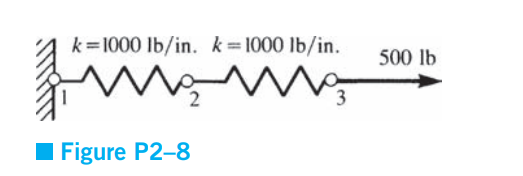

See from the diagram, node 1 is fixed, node 2 and node 3 are free. 500 lb force is applied directly on the node 3, resulting a strech in both spring 0 and spring 1 with the same stiffness 1000 lb/in (the left one is defined as spring 0, and the right one is defined as spring 1).<br>
<br>
Hooke's law and Newtown's third load are applied to solve the problem.<br>
The problem could be solved through four steps, first identifying the global stiffness matrix with indivitual stiffness matrix. Give all the values places to store, like the nodes, elements.

### Step1: Set up for global stiffness matrix<br>
In Step 1, we first define the known parameters and and targeted values.

In [92]:
import numpy as np
import matplotlib.pyplot as plt

Nodes = np.array([1,2,3])
Elements = np.array([(1,2),(2,3)])
Spring_Constants = np.array([1000,1000]) # unit: lb/in
F = np.array([0,0,500]) # unit: lb
Nnd = Nodes.shape[0] # Number of nodes (= number of DOFs in this example)
Nele = Elements.shape[0] # Number of elements
Kg = np.zeros((Nnd,Nnd)) # Initialize the global stiffness matrix

To get global stiffness matrix, we use for loop to combine local stiffness matrix.<br>
For stiffness matrix, with forces on both ends, the local stiffness matrix is [[k,-k],[-k,k]].And the global stiffness is the combination of matrix according to elements.

In [93]:
Ke_all = []
Elem_idx = []
for e in range(Nele):
    # local stiffness matrix
    k = Spring_Constants[e]
    Ke = np.zeros((2,2))
    Ke[0,0] = k; Ke[0,1] = -k; 
    Ke[1,0] = -k; Ke[1,1] = k; 
    Ke_all.append(Ke)
    
    # node indices comprising the elements
    node_i = Elements[e,0]
    node_j = Elements[e,1]
    idx_i = np.nonzero(Nodes==node_i)[0][0]
    idx_j = np.nonzero(Nodes==node_j)[0][0]
    idx = np.array([idx_i,idx_j])
    Elem_idx.append(np.array([idx_i,idx_j]))
    
    # assembly
    Kg[np.ix_(idx, idx)] = Kg[np.ix_(idx, idx)] + Ke 
    #np.ix_ is a NumPy function used to construct an extended indexer object. Here, it is used to create an extended indexer to select specific rows and columns from Kg.
    print("Kg at step {:d}".format(e))
    print(Kg)

Kg at step 0
[[ 1000. -1000.     0.]
 [-1000.  1000.     0.]
 [    0.     0.     0.]]
Kg at step 1
[[ 1000. -1000.     0.]
 [-1000.  2000. -1000.]
 [    0. -1000.  1000.]]


### Step2: obtain the displacement of free nodes<br>
In step2, Hooke's law is applied for figure the relationship between varibles.Since fixed nodes do not has the displacement, classification is first step.

In [94]:
# indices for free/fixed nodes
Fixed_Nodes = [1]
idx_fixed = []
idx_free = []
for i in range(Nnd):
    if Nodes[i] in Fixed_Nodes:
        idx_fixed.append(i)
    else:
        idx_free.append(i)
print("Indices of the fixed nodes: "); 
print(idx_fixed)
print("Indices of the free nodes: "); 
print(idx_free)

Indices of the fixed nodes: 
[0]
Indices of the free nodes: 
[1, 2]


We set the The forces on free nodes 2 and 3, are equal to the Hooke's law is practical. And the equation K_free*u_free=F_free* could be expressed in np.linalg.solve() sentence.

In [95]:
# Applying homogeneous boundary conditions
K_free = Kg[np.ix_(idx_free,idx_free)] 
F_free = F[idx_free]
u_free = np.linalg.solve(K_free,F_free) #solve the function that K_free*u_free=F_free Hooke's law
print(K_free)
print(F_free)
# put the values of u_free into the appropriate elements of the global displacement vector
u = np.zeros(Nnd)
u[idx_free] = u_free
print(u)

[[ 2000. -1000.]
 [-1000.  1000.]]
[  0 500]
[0.  0.5 1. ]


The plot of the original and deformed location of nodes could be plot using the u we calculated out.

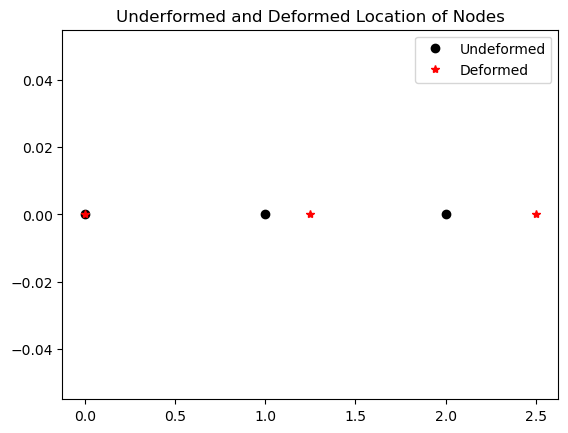

In [96]:
# Plot the original and deformed location of nodes
amp = 0.5
x = np.array([0,1,2]) # the sequence of nodes showing off
y = np.zeros((3))

u_scaled = u/np.abs(u).max() * amp # make the u within [-amp,amp] for better display
plt.plot(x,y,'ok',label='Undeformed')
plt.plot(x+u_scaled,y,'*r',label='Deformed')
plt.title('Underformed and Deformed Location of Nodes')
plt.legend()
plt.show()

### Step3: obtain the reactive force
Reactive forces could be obtained and check with external forces.

In [97]:
F_fixed = Kg[idx_fixed,:] @ u
print(F_fixed)
# Check if the summation of all reaction forces equals the magnitude of the external force
F_fixed.sum()

[-500.]
[  0   0 500]


### Step4: obtain the forces in each spring

In [141]:
for e in range(Nele):
    idx = Elem_idx[e]
    ue = u[idx]
    Ke = Ke_all[e]
    fe = Ke @ ue
    print("Element {:d}".format(e))
    print(fe)

Element 0
[-15.  15.]
Element 1
[-15.  15.]


From the code, we could calculate out that <br>
u_1 = 0 in <br>
u_2 = 0.5 in <br>
u_3 = 1.0 in <br>
f_1x(1) = -500 lb <br>
f_2x(1) = 500 lb <br>
f_2x(2) = -500 lb <br>
f_3x(2) = 500 lb <br>
F_1x = -500 lb <br>

## 2_11

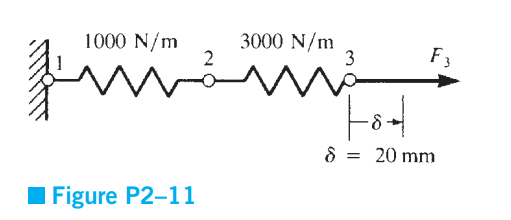

See from the diagram, node 1 is fixed, while node 2 and node 3 are free. An unknow force to the right is applied directly on the node 3, resulting the 20 mm movement of node 3 to the right. The sum of streching length of spring 1 with stiffness 1000 N/m and spring 2 with stiffness 3000 N/m is 20 mm(the left one is defined as spring 1, and the right one is defined as spring 2).

### Step1: Set up for global stiffness matrix<br>
In Step 1, we first define the known parameters and and targeted values.

In [124]:
import numpy as np
import matplotlib.pyplot as plt

Nodes = np.array([1,2,3])
Elements = np.array([(1,2),(2,3)])
Spring_Constants = np.array([1000,3000]) # unit: N/m
u = np.array([0,0,0.020]) # unit: m
Nnd = Nodes.shape[0] # Number of nodes (= number of DOFs in this example)
Nele = Elements.shape[0] # Number of elements
Kg = np.zeros((Nnd,Nnd)) # Initialize the global stiffness matrix
print(u)

[0.   0.   0.02]


To get global stiffness matrix, we use for loop to combine local stiffness matrix.<br>
For stiffness matrix, with forces on both ends, the local stiffness matrix is [[k,-k],[-k,k]].And the global stiffness is the combination of matrix according to elements.

In [125]:
Ke_all = []
Elem_idx = []
for e in range(Nele):
    # local stiffness matrix
    k = Spring_Constants[e]
    Ke = np.zeros((2,2))
    Ke[0,0] = k; Ke[0,1] = -k; 
    Ke[1,0] = -k; Ke[1,1] = k; 
    Ke_all.append(Ke)
    
    # node indices comprising the elements
    node_i = Elements[e,0]
    node_j = Elements[e,1]
    idx_i = np.nonzero(Nodes==node_i)[0][0]
    idx_j = np.nonzero(Nodes==node_j)[0][0]
    idx = np.array([idx_i,idx_j])
    Elem_idx.append(np.array([idx_i,idx_j]))
    
    # assembly
    Kg[np.ix_(idx, idx)] = Kg[np.ix_(idx, idx)] + Ke 
    #np.ix_ is a NumPy function used to construct an extended indexer object. Here, it is used to create an extended indexer to select specific rows and columns from Kg.
    print("Kg at step {:d}".format(e))
    print(Kg)

Kg at step 0
[[ 1000. -1000.     0.]
 [-1000.  1000.     0.]
 [    0.     0.     0.]]
Kg at step 1
[[ 1000. -1000.     0.]
 [-1000.  4000. -3000.]
 [    0. -3000.  3000.]]


### Step2: obtain the displacement of free nodes<br>

Since the "zero" in Kg makes the Hooke's law unsolveable, the focus of the equations falls on free nodes. The first is to seperate the nodes.

In [126]:
# indices for free/fixed nodes
Fixed_Nodes = [1]
idx_fixed = []
idx_free = []
for i in range(Nnd):
    if Nodes[i] in Fixed_Nodes:
        idx_fixed.append(i)
    else:
        idx_free.append(i)
print("Indices of the fixed nodes: "); 
print(idx_fixed)
print("Indices of the free nodes: "); print(idx_free)

Indices of the fixed nodes: 
[0]
Indices of the free nodes: 
[1, 2]


Apply the homogeneous boundary conditions. Since the displacements of elements follow the distribution of Kg proportion. And the calculation of force could be calculated using Hooke's law.

In [138]:
# Applying homogeneous boundary conditions
u[1] = u[2]/(Spring_Constants[1]+Spring_Constants[0])*Spring_Constants[1]
K_free = Kg[np.ix_(idx_free,idx_free)]
u_free=u[idx_free]
F_free = np.dot(K_free, u_free)
u_free= np.linalg.solve(K_free, F_free)
print (K_free)
print(u_free)
print (F_free)
# put the values of u_free into the appropriate elements of the global displacement vector
u = np.zeros(Nnd)
u[idx_free] = u_free
print(u)

[[ 4000. -3000.]
 [-3000.  3000.]]
[0.015 0.02 ]
[7.10542736e-15 1.50000000e+01]
[0.    0.015 0.02 ]


The plot of the original and deformed location of nodes could be plot using the u we calculated out.

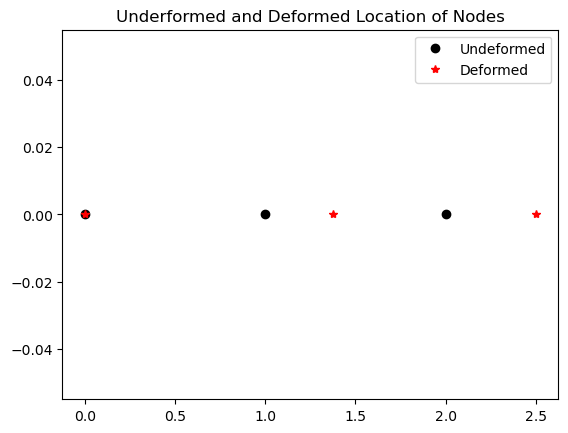

In [132]:
# Plot the original and deformed location of nodes
amp = 0.5
x = np.array([0,1,2]) # the sequence of nodes showing off
y = np.zeros((3))

u_scaled = u/np.abs(u).max() * amp # make the u within [-amp,amp] for better display
plt.plot(x,y,'ok',label='Undeformed')
plt.plot(x+u_scaled,y,'*r',label='Deformed')
plt.title('Underformed and Deformed Location of Nodes')
plt.legend()
plt.show()

### Step3: obtain the reactive force

Reactive forces could be obtained and check with external forces.

In [133]:
F_fixed = Kg[idx_fixed,:] @ u
print(F_fixed)
# Check if the summation of all reaction forces equals the magnitude of the external force
F_fixed.sum()

[-15.]


-15.000000000000007

### Step4: obtain the forces in each spring

In [134]:
for e in range(Nele):
    idx = Elem_idx[e]
    ue = u[idx]
    Ke = Ke_all[e]
    fe = Ke @ ue   
    print("Element {:d}".format(e))
    print(fe)


Element 0
[-15.  15.]
Element 1
[-15.  15.]


From the code, we could calculate out that <br>
u_1 = 0 m <br>
u_2 = 0.015 m <br>
u_3 = 0.020 m <br>
f_1x(1) = -15 N <br>
f_2x(1) = 15 N <br>
f_2x(2) = -15 N <br>
f_3x(2) = 15 N <br>
F_1x = -15 N <br>

## 2_15

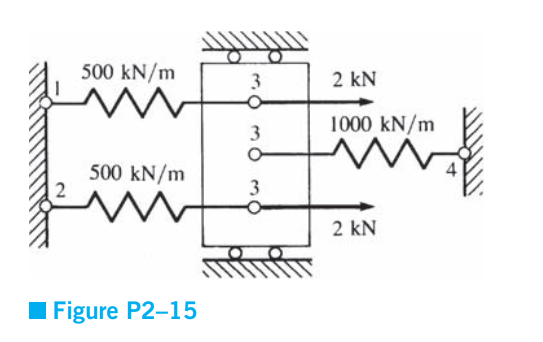

See from the diagram, node 1, 2, and 4 are fixed, while node 3 is free. Two 2kN forces are pulled on the node 3, which results in an unknown displacement of node 3.Two spring are (spring 1 and 2) with stiffness 500 kN/m, and one (spring 3) are with 1000 kN/m. The displacement of spring 1 and 2 keep the same.

### Step1: Set up for global stiffness matrix<br>
First, define the known parameters and and targeted values.

In [114]:
import numpy as np
import matplotlib.pyplot as plt

Nodes = np.array([1,2,3,4])
Elements = np.array([(1,3),(2,3),(3,4)])
Spring_Constants = np.array([500,500,1000]) # unit: kN/m
F = np.array([0,0,4,0]) # unit: kN
Nnd = Nodes.shape[0] # Number of nodes (= number of DOFs in this example)
Nele = Elements.shape[0] # Number of elements
Kg = np.zeros((Nnd,Nnd)) # Initialize the global stiffness matrix

To get global stiffness matrix, we use for loop to combine local stiffness matrix.<br>
For stiffness matrix, with forces on both ends, the local stiffness matrix is [[k,-k],[-k,k]].And the global stiffness is the combination of matrix according to elements.

In [115]:
Ke_all = []
Elem_idx = []
for e in range(Nele):
    # local stiffness matrix
    k = Spring_Constants[e]
    Ke = np.zeros((2,2))
    Ke[0,0] = k; Ke[0,1] = -k; 
    Ke[1,0] = -k; Ke[1,1] = k; 
    Ke_all.append(Ke)
    
    # node indices comprising the elements
    node_i = Elements[e,0]
    node_j = Elements[e,1]
    idx_i = np.nonzero(Nodes==node_i)[0][0]
    idx_j = np.nonzero(Nodes==node_j)[0][0]
    idx = np.array([idx_i,idx_j])
    Elem_idx.append(np.array([idx_i,idx_j]))
    
    # assembly
    Kg[np.ix_(idx, idx)] = Kg[np.ix_(idx, idx)] + Ke 
    #np.ix_ is a NumPy function used to construct an extended indexer object. Here, it is used to create an extended indexer to select specific rows and columns from Kg.
    print("Kg at step {:d}".format(e))
    print(Kg)

Kg at step 0
[[ 500.    0. -500.    0.]
 [   0.    0.    0.    0.]
 [-500.    0.  500.    0.]
 [   0.    0.    0.    0.]]
Kg at step 1
[[ 500.    0. -500.    0.]
 [   0.  500. -500.    0.]
 [-500. -500. 1000.    0.]
 [   0.    0.    0.    0.]]
Kg at step 2
[[  500.     0.  -500.     0.]
 [    0.   500.  -500.     0.]
 [ -500.  -500.  2000. -1000.]
 [    0.     0. -1000.  1000.]]


### Step2: obtain the displacement of free nodes<br>
In step2, Hooke's law is applied for figure the relationship between varibles.Since fixed nodes do not has the displacement, classification is first step.

In [116]:
# indices for free/fixed nodes
Fixed_Nodes = [1,2,4]
idx_fixed = []
idx_free = []
for i in range(Nnd):
    if Nodes[i] in Fixed_Nodes:
        idx_fixed.append(i)
    else:
        idx_free.append(i)
print("Indices of the fixed nodes: "); 
print(idx_fixed)
print("Indices of the free nodes: "); print(idx_free)

Indices of the fixed nodes: 
[0, 1, 3]
Indices of the free nodes: 
[2]


We set the forces on free nodes, and the Hooke's law is practical. And the equation K_free*u_free=F_free* could be expressed in np.linalg.solve() sentence.

In [117]:
# Applying homogeneous boundary conditions
K_free = Kg[np.ix_(idx_free,idx_free)] 
F_free = F[idx_free]
u_free = np.linalg.solve(K_free,F_free) #solve the function that K_free*u_free=F_free Hooke's law
print(K_free)
print(F_free)
# put the values of u_free into the appropriate elements of the global displacement vector
u = np.zeros(Nnd)
u[idx_free] = u_free
print(u)

[[2000.]]
[4]
[0.    0.    0.002 0.   ]


### Step3: obtain the reactive force and check
Reactive forces could be obtained and check with external forces.

In [119]:
F_fixed = Kg[idx_fixed,:] @ u
print(F_fixed)
# Check if the summation of all reaction forces equals the magnitude of the external force
F_fixed.sum()

[-1. -1. -2.]


-4.0

### Step4: obtain the forces in each spring

In [120]:
for e in range(Nele):
    idx = Elem_idx[e]
    ue = u[idx]
    Ke = Ke_all[e]
    fe = Ke @ ue
    print("Element {:d}".format(e))
    print(fe)


Element 0
[-1.  1.]
Element 1
[-1.  1.]
Element 2
[ 2. -2.]


From the code, we could calculate out that <br>
u_1 = 0 m <br>
u_2 = 0 m <br>
u_3 = 0.002 m <br>
u_4 = 0 m <br>
f_1x(1) = -1 kN <br>
f_3x(1) = 1 kN <br>
f_2x(2) = -1 kN <br>
f_3x(2) = 1 kN <br>
f_3x(3) = 2 kN <br>
f_4x(3) = -2 kN <br>
F_1x = -1 N <br>
F_2x = -1 N <br>
F_4x = -2 N <br>